# PU experiments

In [7]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from load_experiment import load_experiment_results 
import datetime 
from helpers import get_n_labels


In [8]:
EXPERIMENT = "c"

In [9]:
df = load_experiment_results(name=EXPERIMENT)
df = df[df["model"]!="oracle"]
df.columns

Index(['c', 'dataset', 'iter', 'model', 'accuracy', '0 precision',
       '1 precision', '0 recall', '1 recall', '0 f1', '1 f1', '0 support',
       '1 support', 'c log'],
      dtype='object')

In [10]:
df["precision"] = (df["0 precision"]+df["1 precision"]) / 2
df["recall"] = (df["0 recall"]+df["1 recall"]) / 2
df["f1"] = (df["0 f1"]+df["1 f1"]) / 2

df[["precision","recall","f1"]] = df[["precision","recall","f1"]].round(4)
df[["precision","recall","f1"]].describe()

,precision,recall,f1
count,960.000000,960.000000,960.000000
mean,0.614939,0.649608,0.572952
std,0.289506,0.205360,0.260692
min,0.000000,0.000000,0.000000
25%,0.319450,0.500000,0.374500
50%,0.715800,0.612150,0.562250
75%,0.842550,0.818800,0.812125
max,1.000000,1.000000,1.000000


In [11]:
fig_experiment_folder = EXPERIMENT
os.makedirs(fig_experiment_folder, exist_ok=True)
current_time = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M")
fig_folder = os.path.join(fig_experiment_folder, f"{current_time}")
os.makedirs(fig_folder, exist_ok=True)

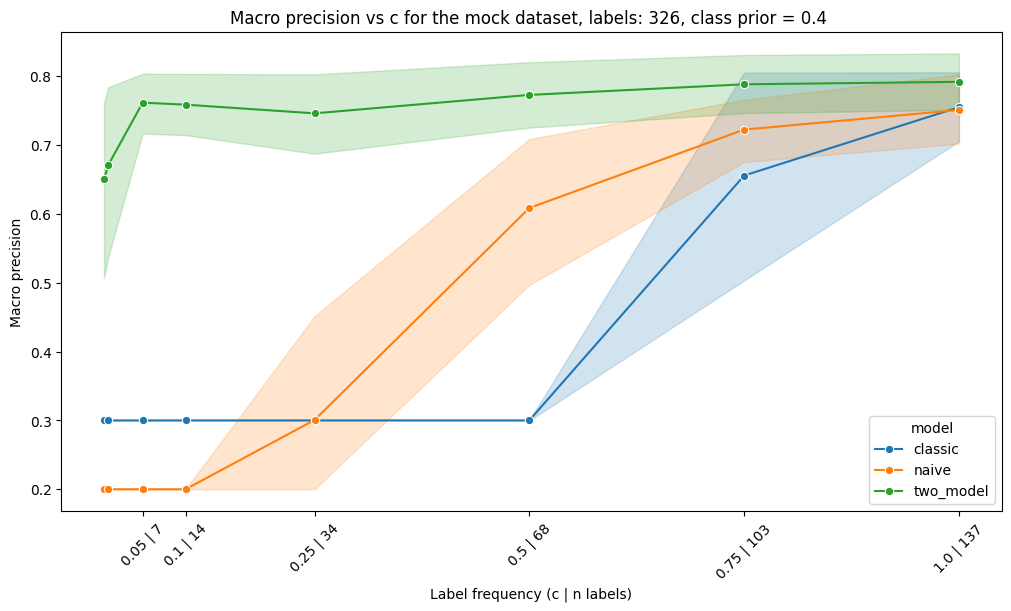

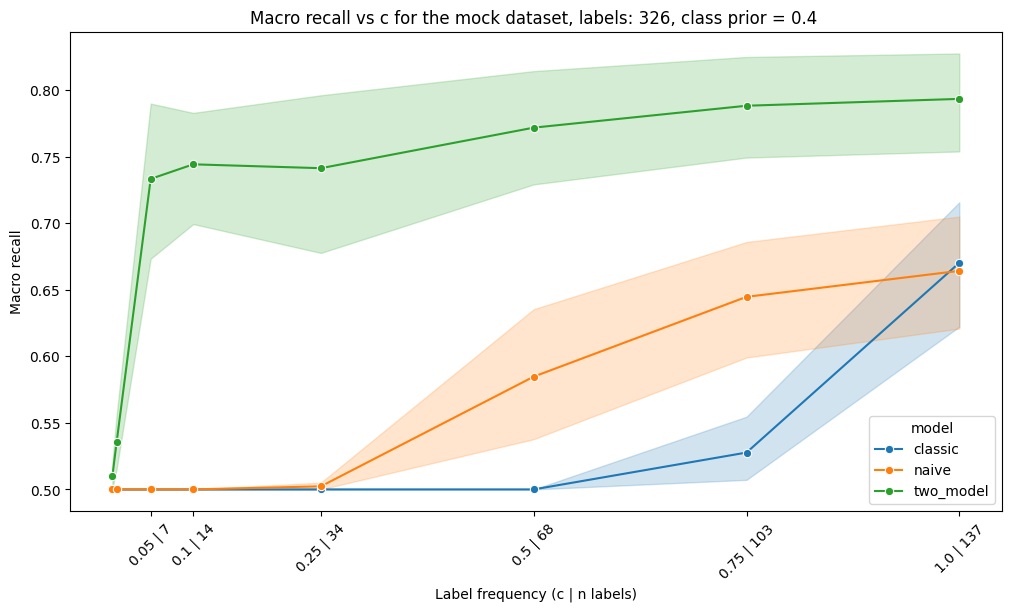

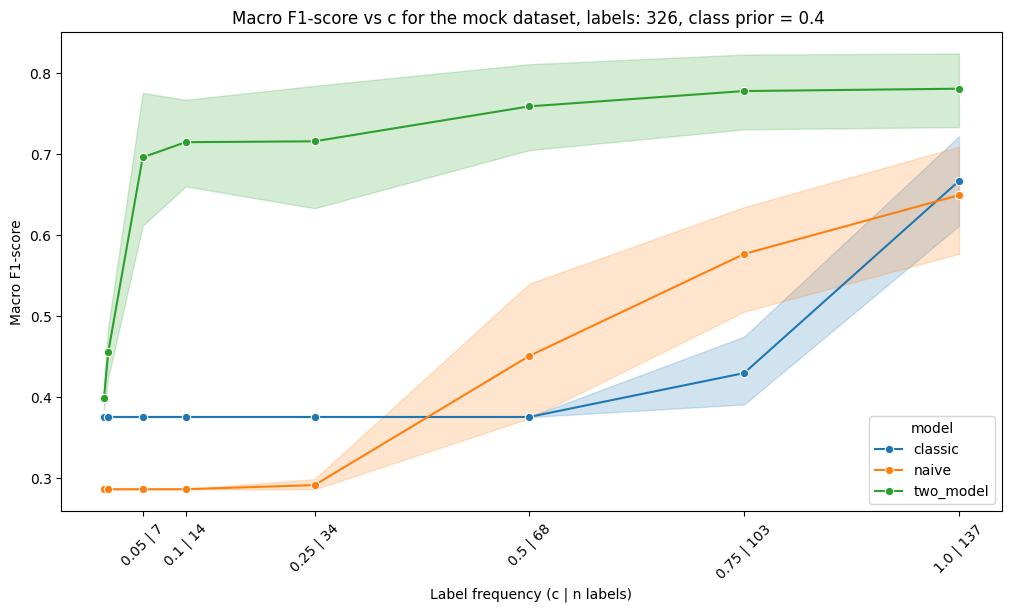

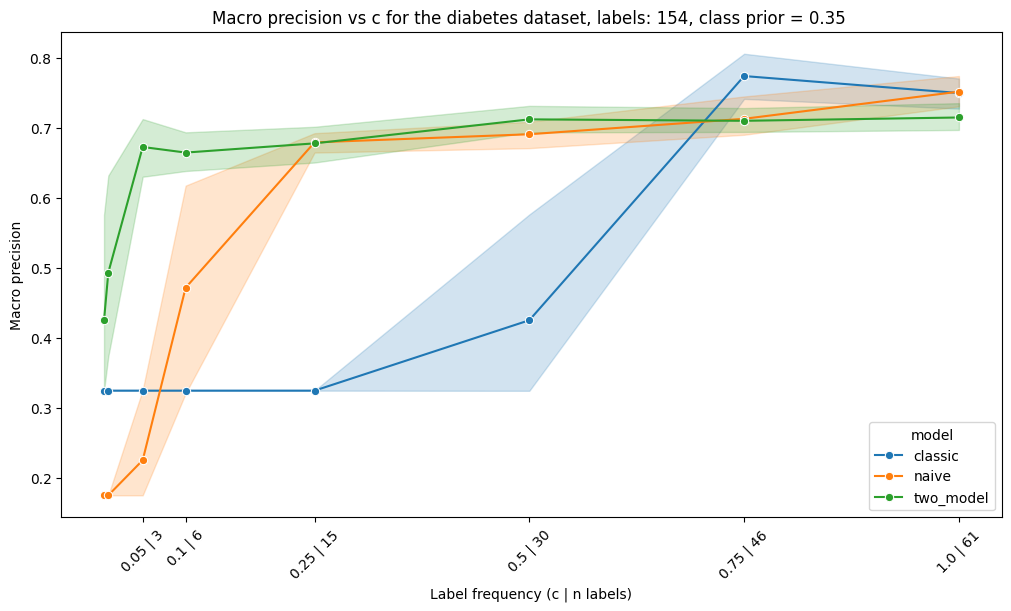

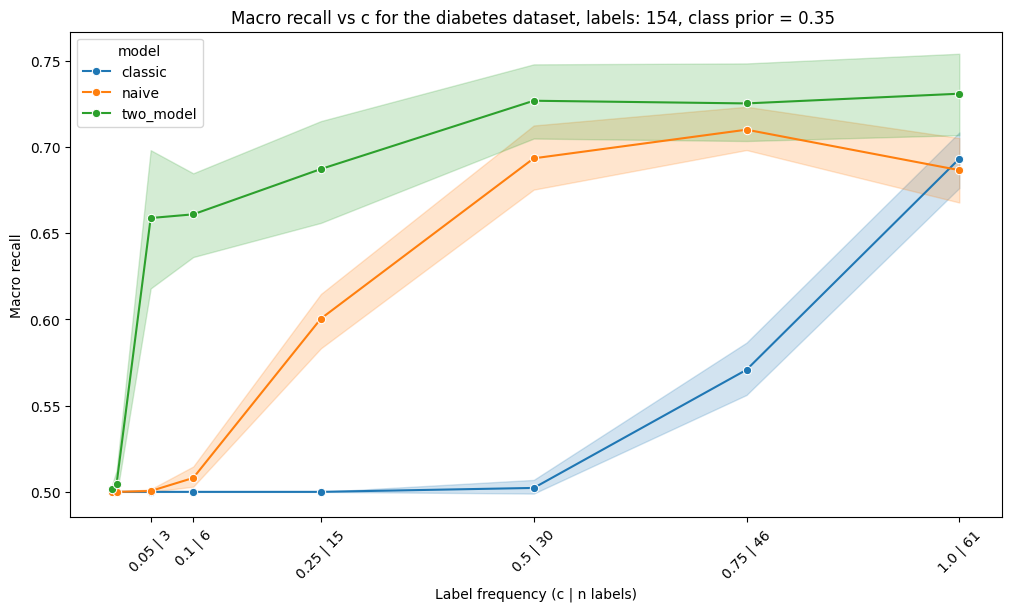

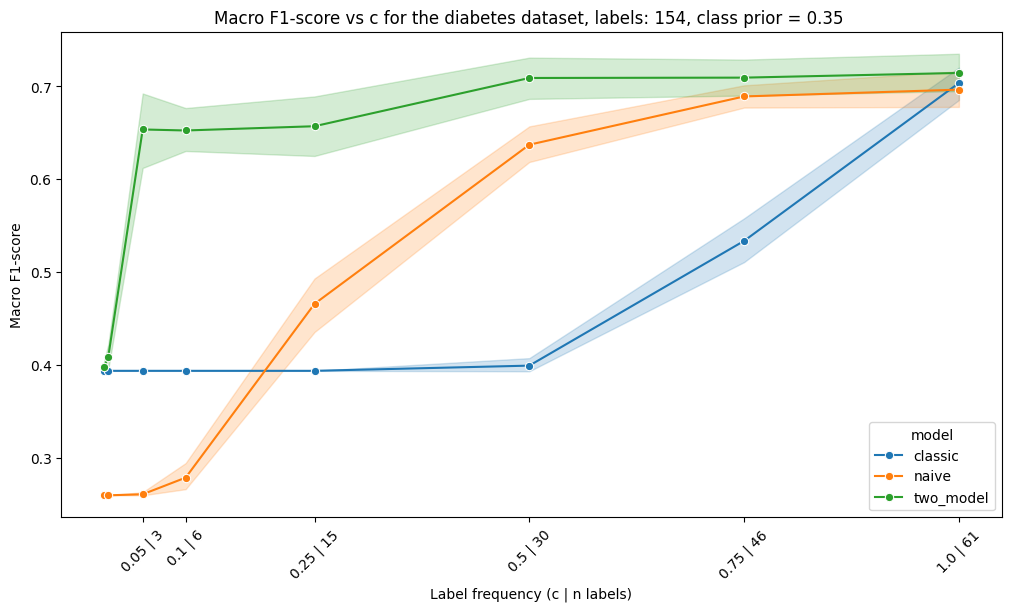

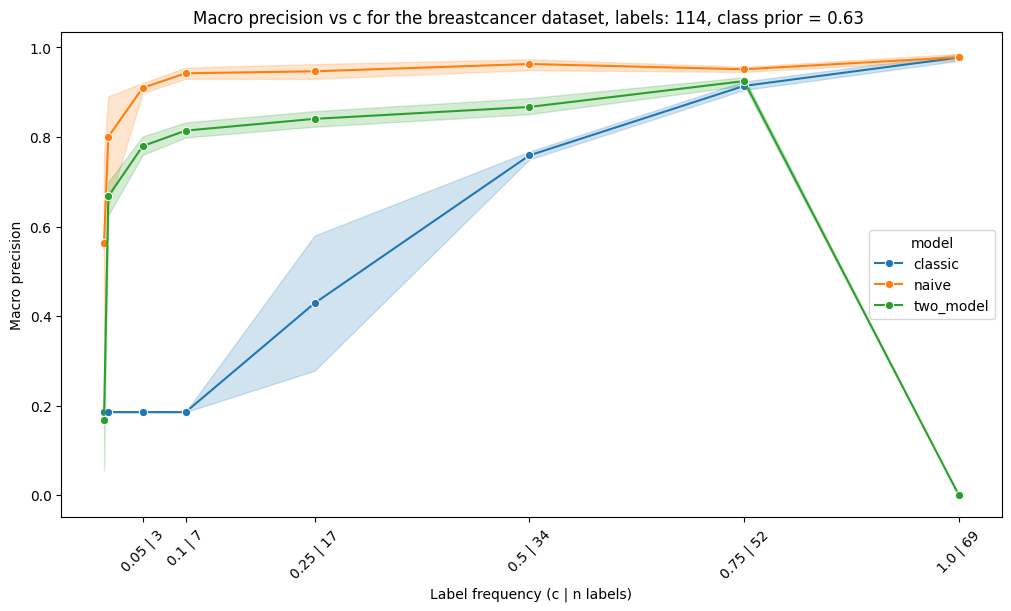

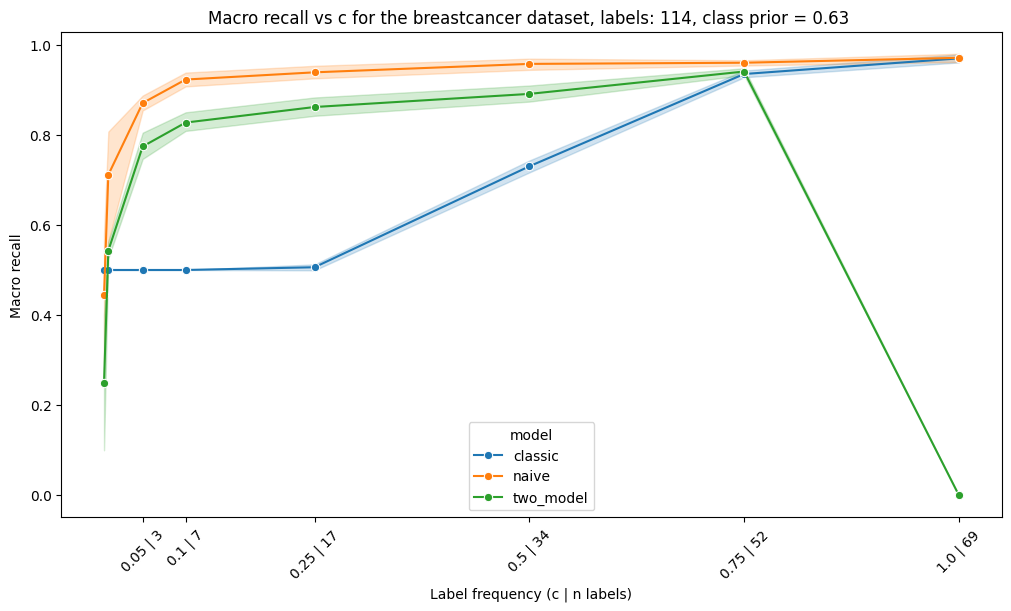

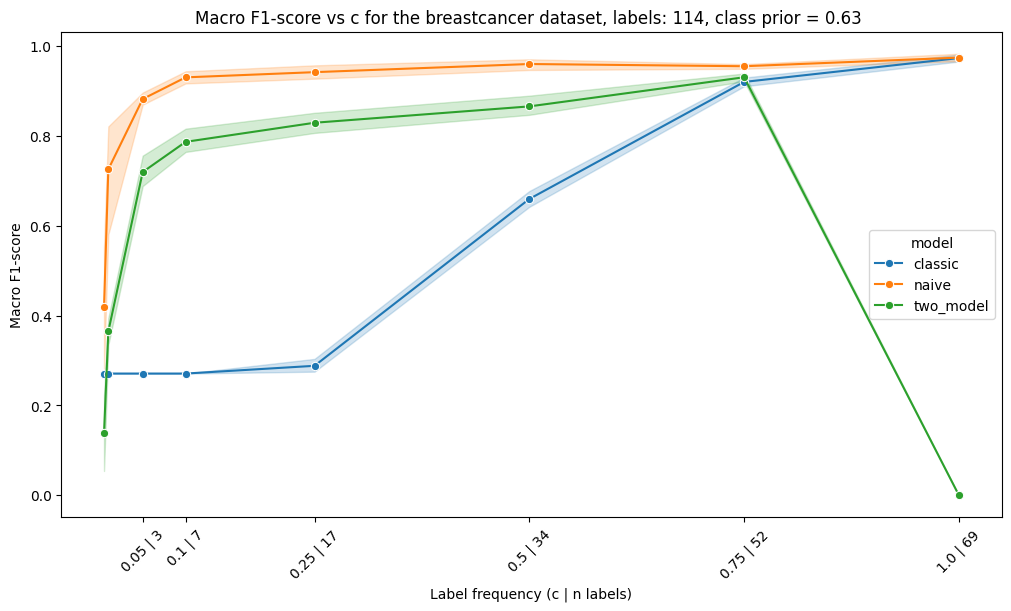

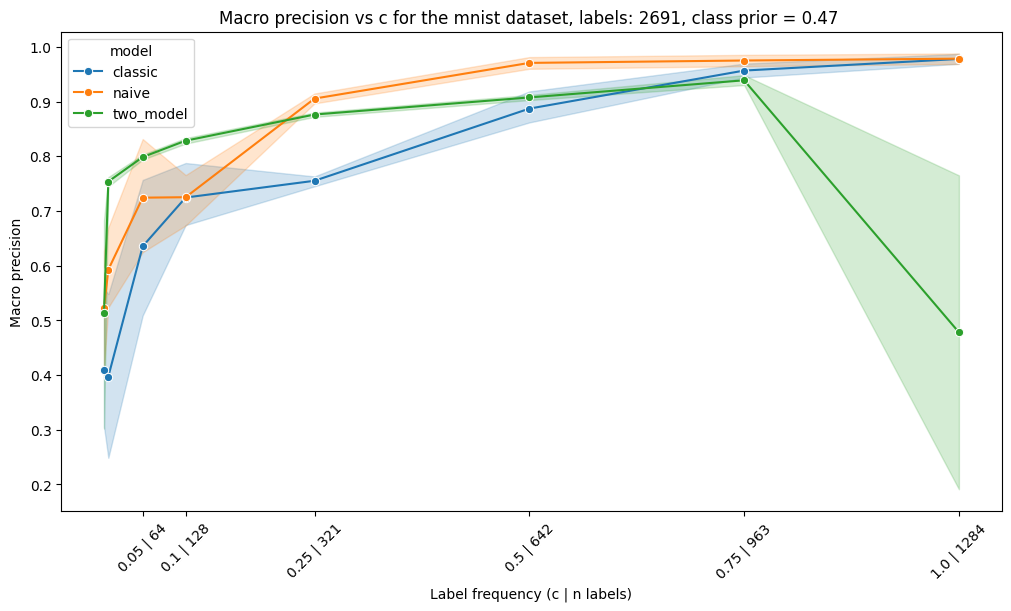

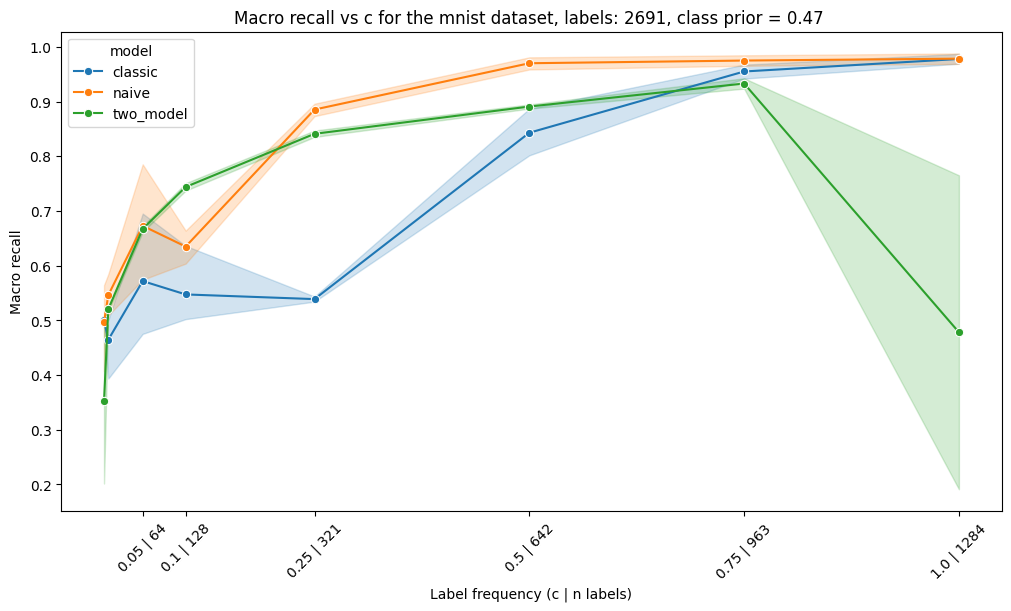

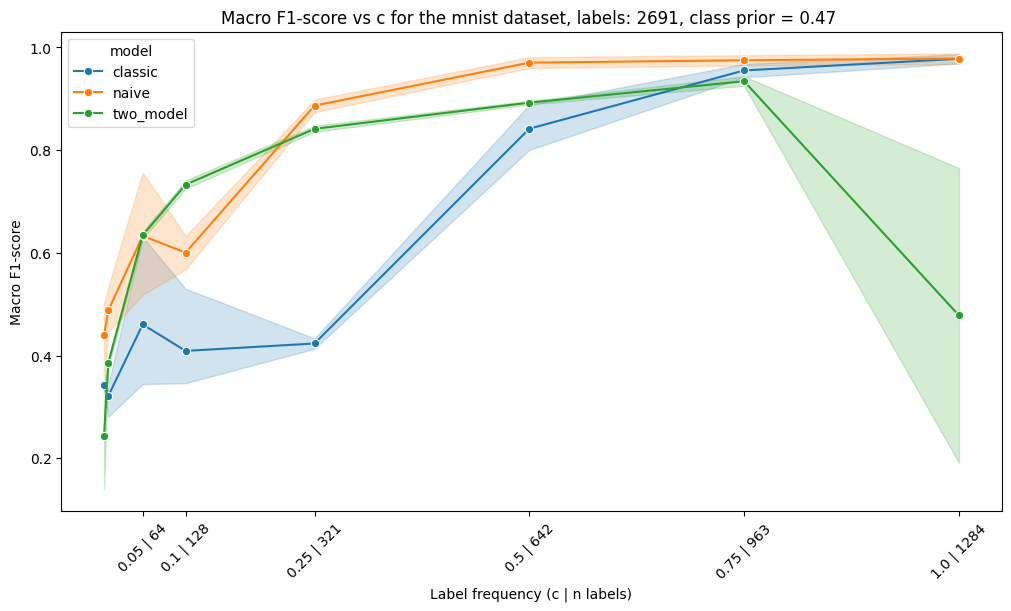

In [19]:

for dataset in df["dataset"].unique():
    assert dataset in ["mock","diabetes","breastcancer","mnist"], f"Unknown dataset: {dataset}"
    c = df["c"].unique().tolist()
    n_labels = get_n_labels(dataset, df["c"].unique())
    ticks = [n_labels[val] for val in c]
    plt.figure(figsize=(10, 6),layout='constrained')
    sns.lineplot(data=df[df["dataset"]==dataset], x="c",y="precision",marker="o",hue="model")
    plt.title(f"Macro precision vs c for the {dataset} dataset, {n_labels['title']} ")
    plt.ylabel("Macro precision")
    plt.xticks(c[2:], ticks[2:],rotation=45)

    plt.xlabel("Label frequency (c | n labels)")
    plt.savefig(os.path.join(fig_folder,f"Precision_macro_{dataset}.png"))
    plt.show()

    plt.figure(figsize=(10, 6),layout='constrained')
    sns.lineplot(data=df[df["dataset"]==dataset], x="c",y="recall",marker="o",hue="model")
    plt.title(f"Macro recall vs c for the {dataset} dataset, {n_labels['title']} ")
    plt.ylabel("Macro recall")
    plt.xticks(c[2:], ticks[2:],rotation=45)
    plt.xlabel("Label frequency (c | n labels)")
    plt.savefig(os.path.join(fig_folder,f"Recall_macro_{dataset}.png"))
    plt.show()

    plt.figure(figsize=(10, 6),layout='constrained')
    sns.lineplot(data=df[df["dataset"]==dataset], x="c",y="f1",marker="o",hue="model")
    plt.title(f"Macro F1-score vs c for the {dataset} dataset, {n_labels['title']} ")
    plt.ylabel("Macro F1-score")
    plt.xticks(c[2:], ticks[2:],rotation=45)
    plt.xlabel("Label frequency (c | n labels)")
    plt.savefig(os.path.join(fig_folder,f"F1_macro_{dataset}.png"))
    plt.show()
